<a href="https://colab.research.google.com/github/sunainakhatwani12/flyrank-ml-internship-sunaina/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sunainakhatwani12/flyrank-ml-internship-sunaina/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [ ]:
# Section 1 — Research question and decision supported

project_question = (
    "Which content items show the strongest evidence that they should "
    "be prioritised for a content refresh?"
)

unit_of_analysis = "One content item"
task_type = "Opportunity scoring and ranking"
decision_supported = (
    "Help a content or SEO team decide which content items to review first."
)
output = "A ranked list of content-refresh opportunities"

print("Research question:")
print(project_question)

print("\nUnit of analysis:")
print(unit_of_analysis)

print("\nTask type:")
print(task_type)

print("\nDecision supported:")
print(decision_supported)

print("\nOutput:")
print(output)

Research question:
Which content items show the strongest evidence that they should be prioritised for a content refresh?

Unit of analysis:
One content item

Task type:
Opportunity scoring and ranking

Decision supported:
Help a content or SEO team decide which content items to review first.

Output:
A ranked list of content-refresh opportunities


### Research question

Which content items show the strongest evidence that they should be prioritised for a content refresh?

This project treats each content item as one unit of analysis. It uses historical search-performance signals to estimate and rank refresh opportunities.

The decision supported by this work is: **which content items should an SEO or content team review first when time and resources are limited?**

The output is a ranked opportunity score rather than an automatic publishing decision. A high score means that the item should receive human review before lower-ranked items.

This is a decision-support project. It does not claim that refreshing a page will directly cause improved search performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:
# Section 2 — Data summary

dataset_name = "FlyRank ML Internship Warehouse Release"
time_window = "~17 months"
unit = "Content item"

excluded = [
    "Client names",
    "URLs",
    "Private search queries",
    "Personally identifiable information"
]

print("Dataset:", dataset_name)
print("Coverage:", time_window)
print("Unit of analysis:", unit)

print("\nExcluded from analysis:")
for item in excluded:
    print("-", item)

Dataset: FlyRank ML Internship Warehouse Release
Coverage: ~17 months
Unit of analysis: Content item

Excluded from analysis:
- Client names
- URLs
- Private search queries
- Personally identifiable information


## Data

This project uses the FlyRank ML Internship warehouse release, a pseudonymized search-performance dataset covering approximately 17 months of historical data. The analysis focuses on content-level search signals generated from production search performance.

The analysis uses aggregated content-level features derived from the warehouse tables. Private client information, URLs, search queries, and any identifying information are excluded from the analysis to maintain public safety.

The dataset is used only for educational and research purposes within the FlyRank ML Internship. Results are reported only as aggregated statistics and model performance metrics.

Excluded data:
- Client names
- URLs
- Search queries
- Personally identifiable information
- Any information that could identify a customer

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
# Section 3 — Methodology summary

methodology = {
    "task": "Content refresh opportunity scoring and ranking",
    "label": "is_declining_label derived from trend_direction",
    "baseline_rule": {
        "stale_threshold_days": 180,
        "visibility_threshold_impressions": 300,
        "staleness_points": 60,
        "visibility_points": 40,
        "maximum_score": 100
    },
    "models": [
        "Logistic Regression",
        "Random Forest"
    ],
    "validation": {
        "split_type": "Grouped train/test split by client_id",
        "training_clients": 24,
        "test_clients": 8,
        "client_overlap": 0,
        "primary_metric": "Precision@50"
    },
    "leakage_protection": [
        "No label-derived predictive features",
        "No client or content identifiers used as features",
        "No future-window outcomes",
        "No existing action flags",
        "No client overlap in the grouped split"
    ]
}

print("METHODOLOGY SUMMARY")
print("-" * 60)

print("Task:", methodology["task"])
print("Label:", methodology["label"])

print("\nBaseline rule:")
for key, value in methodology["baseline_rule"].items():
    print(f"- {key}: {value}")

print("\nModels:")
for model in methodology["models"]:
    print("-", model)

print("\nValidation:")
for key, value in methodology["validation"].items():
    print(f"- {key}: {value}")

print("\nLeakage protection:")
for check in methodology["leakage_protection"]:
    print("-", check)

METHODOLOGY SUMMARY
------------------------------------------------------------
Task: Content refresh opportunity scoring and ranking
Label: is_declining_label derived from trend_direction

Baseline rule:
- stale_threshold_days: 180
- visibility_threshold_impressions: 300
- staleness_points: 60
- visibility_points: 40
- maximum_score: 100

Models:
- Logistic Regression
- Random Forest

Validation:
- split_type: Grouped train/test split by client_id
- training_clients: 24
- test_clients: 8
- client_overlap: 0
- primary_metric: Precision@50

Leakage protection:
- No label-derived predictive features
- No client or content identifiers used as features
- No future-window outcomes
- No existing action flags
- No client overlap in the grouped split


### Methodology

This project compares a transparent rule-based baseline with learned classification models for ranking content-refresh opportunities.

#### Label definition

The evaluation target is `is_declining_label`. It is created from `trend_direction`:

- `1` means the observed direction is down.
- `0` means the observed direction is not down.

This label is a directional proxy. It does not prove that a page requires a refresh or that refreshing it will cause performance to improve.

#### Week 4 baseline

The baseline identifies a page as eligible for refresh review when:

- `days_since_last_update >= 180`
- `impressions_90d >= 300`

Its score contains:

- Up to 60 points for staleness.
- Up to 40 points for search visibility.

The maximum baseline score is 100. The score is a ranking score, not a probability.

#### Models

I compared the baseline with:

1. Logistic Regression
2. Random Forest

The models use historical content, search-performance, engagement, keyword, and categorical features. Examples include:

- Days since the last update
- Content age
- Impressions, clicks, sessions, and users
- CTR and average position
- Engagement rate and scroll rate
- Word count and character count
- Search volume and competition
- Content type and search intent

#### Validation design

The final evaluation uses a grouped client split.

- Approximately 75% of clients are used for training.
- Approximately 25% of clients are held out for testing.
- All pages belonging to one client remain on only one side of the split.
- There is no client overlap between the training and test sets.

This is more honest than randomly splitting individual rows because a random-row split can place pages from the same client in both training and testing.

#### Evaluation

The primary ranking metric is Precision@50. It measures the percentage of observed declining pages among the first 50 ranked recommendations.

The baseline and models are compared on the same held-out test split.

#### Leakage checks

The model does not use:

- `trend_direction` as a predictive feature
- `is_declining_label` as a predictive feature
- Client or content identifiers as predictive features
- Future or comparison-window outcomes
- Existing FlyRank action flags

Zero values in `avg_position` are treated as missing values, and a missingness indicator is created.

The final output is decision support for human review, not an automatic content-editing system.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
# Section 4 — Final audited results

import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Method": [
        "Week 4 rule baseline",
        "Random Forest"
    ],
    "Precision@20": [
        0.75,
        0.50
    ],
    "Precision@50": [
        0.70,
        0.54
    ],
    "Precision@100": [
        0.65,
        0.49
    ]
})

print("FINAL AUDITED COMPARISON")
print("-" * 60)

display(
    results.style.format({
        "Precision@20": "{:.2%}",
        "Precision@50": "{:.2%}",
        "Precision@100": "{:.2%}"
    })
)

baseline_p50 = results.loc[
    results["Method"] == "Week 4 rule baseline",
    "Precision@50"
].iloc[0]

model_p50 = results.loc[
    results["Method"] == "Random Forest",
    "Precision@50"
].iloc[0]

difference = baseline_p50 - model_p50

print("\nPrimary result:")
print(f"Baseline Precision@50: {baseline_p50:.2%}")
print(f"Random Forest Precision@50: {model_p50:.2%}")
print(
    "Difference in favour of baseline: "
    f"{difference:.2%}"
)

FINAL AUDITED COMPARISON
------------------------------------------------------------


,Method,Precision@20,Precision@50,Precision@100
0,Week 4 rule baseline,75.00%,70.00%,65.00%
1,Random Forest,50.00%,54.00%,49.00%



Primary result:
Baseline Precision@50: 70.00%
Random Forest Precision@50: 54.00%
Difference in favour of baseline: 16.00%


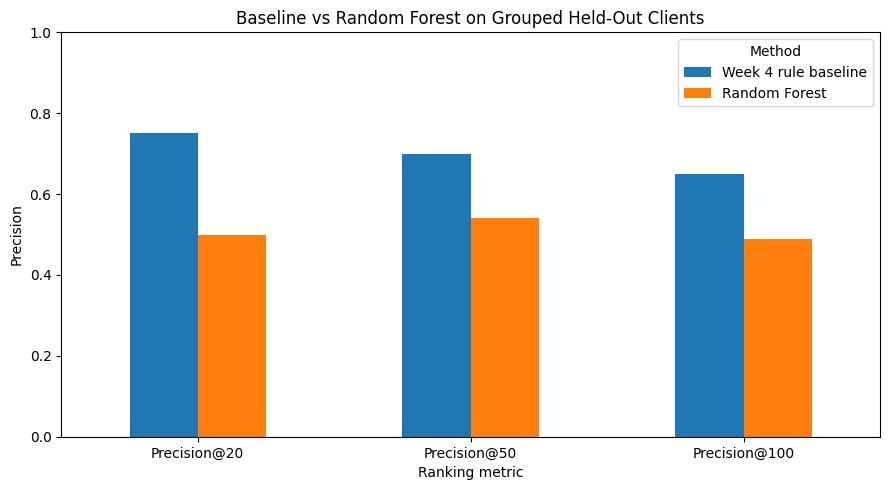

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Recreate the results so this cell can run independently
chart_results = pd.DataFrame({
    "Method": ["Week 4 rule baseline", "Random Forest"],
    "Precision@20": [0.75, 0.50],
    "Precision@50": [0.70, 0.54],
    "Precision@100": [0.65, 0.49]
})

chart_data = chart_results.set_index("Method")

ax = chart_data.transpose().plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Baseline vs Random Forest on Grouped Held-Out Clients")
ax.set_xlabel("Ranking metric")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1)
ax.legend(title="Method")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Results

The final audited comparison uses the same grouped held-out client test rows for both the Week 4 rule baseline and the Random Forest model.

| Method | Precision@20 | Precision@50 | Precision@100 |
|---|---:|---:|---:|
| Week 4 rule baseline | 75.00% | 70.00% | 65.00% |
| Random Forest | 50.00% | 54.00% | 49.00% |

The Week 4 baseline produced the stronger measured ranking result in this final validation setup.

At the primary metric, Precision@50:

- The baseline achieved **70.00%**.
- The Random Forest achieved **54.00%**.
- The measured difference was **16 percentage points in favour of the baseline**.

This means that 70% of the first 50 pages ranked by the baseline had the observed declining label, compared with 54% of the first 50 pages ranked by the Random Forest.

The learned model therefore did not beat the transparent rule baseline under this grouped-client validation design.

This result should not be interpreted as proof that the baseline will always outperform machine learning. It applies only to this dataset, label proxy, held-out client split, and evaluation procedure.

An earlier model-training comparison produced different results because of differences in how the evaluation was conducted. The Week 6 validation audit is treated as the final result because it directly compares the baseline and model on the same grouped held-out rows.

## 5. Limitations

*What this work cannot claim.*

In [ ]:
# Section 5 — Limitations summary

limitations = [
    "The decline label is a proxy and does not prove that a refresh is needed.",
    "Historical data cannot capture seasonality, topic accuracy, or editorial plans.",
    "The system cannot measure business value or conversion importance directly.",
    "Technical SEO issues may be more important than content freshness.",
    "The final result depends on one grouped client train/test split.",
    "Precision@50 does not measure real post-refresh traffic impact.",
    "The analysis shows association and ranking quality, not causation.",
    "Every recommendation requires human review before action."
]

print("PROJECT LIMITATIONS")
print("-" * 60)

for number, limitation in enumerate(limitations, start=1):
    print(f"{number}. {limitation}")

PROJECT LIMITATIONS
------------------------------------------------------------
1. The decline label is a proxy and does not prove that a refresh is needed.
2. Historical data cannot capture seasonality, topic accuracy, or editorial plans.
3. The system cannot measure business value or conversion importance directly.
4. Technical SEO issues may be more important than content freshness.
5. The final result depends on one grouped client train/test split.
6. Precision@50 does not measure real post-refresh traffic impact.
7. The analysis shows association and ranking quality, not causation.
8. Every recommendation requires human review before action.


### Limitations

This project has several important limitations.

First, the target `is_declining_label` is only a proxy created from the observed search trend. It does not prove that a page is outdated, that its content quality is poor, or that refreshing it will cause performance to improve.

Second, the dataset contains historical search and content signals, but it does not contain every factor that may influence performance. The model cannot directly observe:

- Whether a topic is seasonal
- Whether a page is intentionally evergreen
- Whether a refresh is already planned
- Whether the page has recently been updated but the change is not yet reflected in the data
- Whether the impressions come from irrelevant searches
- Whether a technical SEO issue is more important than the content itself
- Whether the page has meaningful business or conversion value
- Whether the page should instead be deleted, consolidated, or redirected

Third, the baseline is based mainly on staleness and search visibility. A highly visible old page may still be accurate and may not need a refresh.

Fourth, the Random Forest result depends on one grouped client split. A different held-out set of clients could produce different results.

Fifth, Precision@50 measures ranking quality at the top of the queue, but it does not measure the actual traffic or business impact after a page is refreshed.

Sixth, the comparison does not establish causation. A recommended page should still be reviewed by a human before any editorial action is taken.

The output should therefore be treated as decision support, not as an automatic publishing or content-editing system.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [ ]:
# Section 6 — Ranked action playbook

recommendations = [
    {
        "rank": 1,
        "action": "Review highest-ranked stale and visible pages",
        "reason": "These pages show the strongest baseline opportunity signals."
    },
    {
        "rank": 2,
        "action": "Prioritise pages with meaningful existing visibility",
        "reason": "Existing impressions indicate that search exposure may be protected or improved."
    },
    {
        "rank": 3,
        "action": "Investigate uncertain recommendations",
        "reason": "Seasonality, healthy CTR, weak rankings, or technical issues may make a refresh inappropriate."
    },
    {
        "rank": 4,
        "action": "Require human approval",
        "reason": "The score cannot understand topic accuracy, business value, or editorial plans."
    },
    {
        "rank": 5,
        "action": "Monitor outcomes after action",
        "reason": "Post-action evidence is needed to determine whether the recommendation was useful."
    }
]

print("RANKED RECOMMENDATIONS")
print("-" * 70)

for item in recommendations:
    print(f"\n{item['rank']}. {item['action']}")
    print(f"   Why: {item['reason']}")

RANKED RECOMMENDATIONS
----------------------------------------------------------------------

1. Review highest-ranked stale and visible pages
   Why: These pages show the strongest baseline opportunity signals.

2. Prioritise pages with meaningful existing visibility
   Why: Existing impressions indicate that search exposure may be protected or improved.

3. Investigate uncertain recommendations
   Why: Seasonality, healthy CTR, weak rankings, or technical issues may make a refresh inappropriate.

4. Require human approval
   Why: The score cannot understand topic accuracy, business value, or editorial plans.

5. Monitor outcomes after action
   Why: Post-action evidence is needed to determine whether the recommendation was useful.


### Ranked Recommendations

The final action playbook uses the transparent Week 4 baseline because it performed better than the Random Forest in the final grouped validation.

The ranked queue should be used in the following order:

#### 1. Review the highest-ranked stale and visible pages first

Pages with the strongest combination of staleness and search visibility should receive the earliest human review.

Recommended action:

- Check whether the information is outdated.
- Check whether the search intent has changed.
- Check whether important sections, examples, statistics, or links need updating.
- Confirm that the page still supports a useful business goal.

#### 2. Prioritise pages with meaningful existing visibility

A page with strong impressions already has search exposure. Improving a visible page may protect or improve traffic more effectively than starting with a page that receives almost no search attention.

Impressions are treated as an opportunity signal, not as proof that a refresh will work.

#### 3. Investigate weak or uncertain recommendations

Before refreshing a page, check whether:

- Its topic is seasonal.
- It is intentionally evergreen and still correct.
- It already has healthy click-through performance.
- It ranks too deeply for a content refresh alone to help.
- Its impressions are not producing useful visits.
- A technical SEO issue is the real problem.
- It is already planned for deletion, redirection, or consolidation.

#### 4. Use human review before publishing changes

The ranked score should create a review queue. It should not automatically edit or publish content.

A reviewer should confirm:

- The page is still relevant.
- The page has useful business or audience value.
- A refresh is the appropriate action.
- No other editorial or technical work is already planned.

#### 5. Monitor outcomes after action

After refreshing a page, monitor:

- Search impressions
- Clicks
- CTR
- Average position
- Sessions
- Engagement
- Conversion or business outcomes, when available

Compare post-refresh performance with an appropriate earlier period while accounting for seasonality and reporting delays.

#### Final action playbook

1. Generate the ranked queue.
2. Start with the highest-ranked pages.
3. Perform a manual content and business review.
4. Select the correct action: refresh, monitor, consolidate, redirect, or take no action.
5. Record the reason for the decision.
6. Measure results after the action.
7. Use the new evidence to improve future ranking rules.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
# Section 7 — Artifacts

artifacts = [
    "capstone.ipynb",
    "GitHub repository",
    "Baseline vs Random Forest chart",
    "Results table",
    "Ranked content queue",
    "Baseline metrics",
    "Validation metrics",
    "Action playbook",
    "Supporting JSON outputs"
]

print("PROJECT ARTIFACTS")
print("-" * 60)

for i, artifact in enumerate(artifacts, start=1):
    print(f"{i}. {artifact}")

PROJECT ARTIFACTS
------------------------------------------------------------
1. capstone.ipynb
2. GitHub repository
3. Baseline vs Random Forest chart
4. Results table
5. Ranked content queue
6. Baseline metrics
7. Validation metrics
8. Action playbook
9. Supporting JSON outputs


### Artifacts

The deployed research paper includes the following supporting artifacts.

## Notebook

- work/notebooks/capstone.ipynb

## Repository

The complete source code, notebooks, and outputs are available in the project GitHub repository.

## Figures

The paper includes:

- Baseline vs Random Forest comparison chart
- Precision comparison table

## Outputs

The repository contains generated outputs including:

- Ranked content queue
- Baseline metrics
- Validation metrics
- Action playbook
- Supporting JSON summaries

## Reproducibility

The repository contains the notebooks and code required to reproduce the analysis using the FlyRank ML Internship dataset.

The work is intended for educational and research purposes.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
